# Procesamiento Digital de Imágenes - TP02a: Operaciones Puntuales

Objetivos de la guía:

* Introducir conceptos de realce de imágenes mediante operaciones puntuales.
* Conocer aspectos de implementación práctica de algoritmos de procesamiento espacial.
* Comprobar los efectos de operaciones aritméticas y lógicas mediante la validación de algoritmos.

In [6]:
# Recuerda siempre la Configuración Inicial
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider
import ipywidgets as widgets

# Función auxiliar para mostrar imágenes en Colab
def mostrar_imagen(imagen, titulo="Imagen", cmap=None):
    plt.figure(figsize=(6, 6))
    if cmap is None and len(imagen.shape) == 3:
        imagen = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
    plt.imshow(imagen, cmap=cmap)
    plt.title(titulo)
    plt.axis('off')
    plt.show()

print("Entorno configurado. ¡Asegúrate de subir las imágenes de prueba al entorno de Colab!")

Entorno configurado. ¡Asegúrate de subir las imágenes de prueba al entorno de Colab!


## Ejercicio 1: Transformaciones lineales de una imagen

La ecuación general de una transformación lineal es $s=ar+c$, donde $r$ es el valor de entrada, $a$ el factor de ganancia y $c$ el offset.

**Tareas:**

* Implemente una **LUT** (Look-Up Table) del mapeo.
* Pruebe con diferentes coeficientes $a$ y $c$, mostrando la original, el mapeo y el resultado.
* Implemente el negativo de la imagen.
* Genere **LUTs** con estiramientos por tramos.

* Implementar el Negativo de la imagen (¿qué valores de 'a' y 'c' generan un negativo?)
* (Opcional) Implementar la captura de puntos con matplotlib para transformaciones por tramos.

In [ ]:
def aplicar_transformacion_lineal(img_path, a, c):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print ("Carga una imagen válida.")
        return

    # 1. Crear la LUT (Arreglo de 256 valores)
    lut = np.zeros(256, dtype=np.uint8)
    lut = np.clip(np.arange(256)*a + c, 0, 255).astype(np.uint8) # Esto crea la LUT con el mapeo lineal y la limita a [0, 255]

    # 2. Aplicar la LUT a la imagen (puedes usar cv2.LUT)
    img_transformada = cv2.LUT(img, lut) #que hará esto no?)

    # 3. Visualización (Original, Mapeo, Resultado)
    fig, axs = plt.subplots(1, 3, figsize=(15, 4))

    axs[0].imshow(img, cmap='gray', vmin=0, vmax=255)
    axs[0].set_title('Imagen Original')
    axs[0].axis('off')

    # Mapeo
    r = np.arange(256)
    axs[1].plot(r, lut)
    axs[1].set_title(f'Mapeo Lineal (a={a}, c={c})')
    axs[1].set_xlim(0, 255)
    axs[1].set_ylim(0, 255)
    axs[1].grid(True)

    axs[2].imshow(img_transformada, cmap='gray', vmin=0, vmax=255)
    axs[2].set_title('Imagen Transformada')
    axs[2].axis('off')

    plt.show()


interact(
    aplicar_transformacion_lineal,
    img_path="../Imagenes_cursado/rmn.jpg",
    a=FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0),
    c=IntSlider(min=-100, max=100, step=5, value=0)
)


interactive(children=(Text(value='../Imagenes_cursado/rmn.jpg', description='img_path'), FloatSlider(value=1.0…

<function __main__.aplicar_transformacion_lineal(img_path, a, c)>

## Ejercicio 2: Transformaciones no lineales

* Implemente la transformación logarítmica $s=log(1+r)$ y la transformación de potencia $s=r^\gamma$ (con $c=1$).
*  Evalúe los resultados sobre la imagen `rmn.jpg` y alguna otra para la cual usted considere que la transformación es útil.


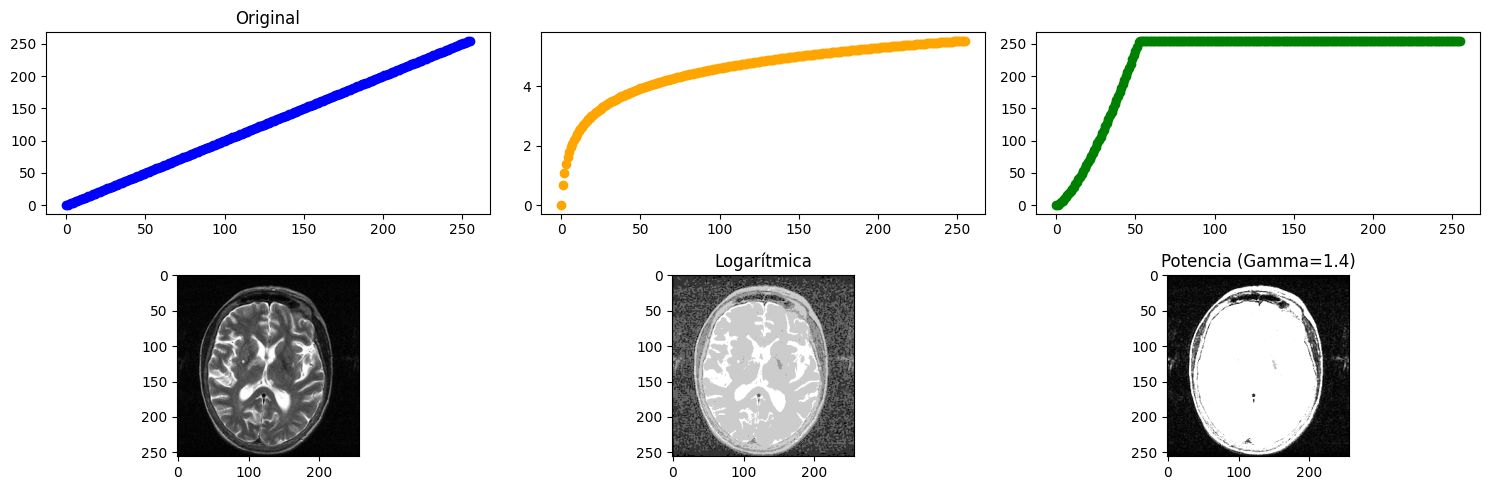

In [8]:
def transformaciones_no_lineales(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print("Sube la imagen 'rmn.jpg'")
        return

    # IMPORTANTE: Para operaciones matemáticas, convertir a float
    #img_float = img.astype(np.float32) para que las convierte a float????

    # 1. Transformación Logarítmica: s = log(1 + r)

    lut = np.clip(np.log(1 + np.arange(0, 256)), 0, 255).astype(np.uint8)
    img_log = cv2.LUT(img, lut)

    # 2. Transformación de Potencia (Gamma): s = r^gamma
    gamma = 1.4
    lut = np.clip(np.arange(0,256)**gamma, 0,255).astype(np.uint8)
    
    img_gamma = cv2.LUT(img, lut)

    # Mostrar resultados
    fig, axs = plt.subplots(2, 3, figsize=(15, 5))
    axs[0,0].scatter(np.arange(256), np.arange(256), color='blue', label='Identidad')
    axs[0,1].scatter(np.arange(256), np.clip(np.log(1 + np.arange(0, 256)), 0, 255), color='orange', label='Logarítmica')
    axs[0,2].scatter(np.arange(256), np.clip(np.arange(0,256)**gamma, 0,255), color='green', label=f'Potencia (Gamma={gamma})')


    axs[1,0].imshow(img, cmap='gray'); axs[0,0].set_title("Original")
    axs[1,1].imshow(img_log, cmap='gray'); axs[1,1].set_title("Logarítmica")
    axs[1,2].imshow(img_gamma, cmap='gray'); axs[1,2].set_title(f"Potencia (Gamma={gamma})")
    plt.tight_layout()
    plt.show()

transformaciones_no_lineales('../Imagenes_cursado/rmn.jpg')


## Ejercicio 3: Operaciones aritméticas

* Implemente funciones para sumar, restar y multiplicar imágenes.
* Utilice un video de seguridad (**pedestrians.mp4**) para obtener el fondo promediando frames, use un slider para elegir el número de frames a promediar.

---

Las funciones que se usarán para leer y extraer frames del video son:
* cap = cv2.VideoCapture()
* ret, frame = cap.read() -> *Lee un frame y deja el puntero en el próximo*
* cap.release()



In [11]:
# 1. Operaciones Básicas
def operaciones_aritmeticas(img1, img2, mascara):
    suma=(img1 + img2)/2
    
    resta_2= (img1 - img2 + 255) / 2

    diff = img1-img2
    min_val = diff.min()
    max_val = diff.max()

    resta_escalada = (diff-min_val)/(max_val-min_val)*255
    
    # mascara binaria (0,1)
    if mascara.max()==255:
        mascara_binaria = mascara // 255
    else:
        mascara_binaria = mascara
    
    multiplicacion = img1*mascara_binaria

    return suma, resta_2, multiplicacion


In [12]:
cap = cv2.VideoCapture('../Imagenes_cursado/pedestrians.mp4')


In [13]:
# 2. Extracción de fondo en video usando ipywidgets en lugar de cv2.Trackbar
def extraer_fondo(num_frames_a_promediar):
    # Arreglar el path
    cap = cv2.VideoCapture('../Imagenes_cursado/pedestrians.mp4') #objeto videocaptura
    if not cap.isOpened():
        return "Sube el video 'pedestrians.mp4'"

    # Acumulador para la suma de frames (usar float32 para no desbordar)

    frames_leidos = 0
    acumulador = None
    while(cap.isOpened() and frames_leidos < num_frames_a_promediar):
        ret, frame = cap.read() #aca leo un frame
        if not ret: #es que ya no hay mas frames
            print(frames_leidos)
            break #entonces romper

        frame_gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY) #convierto el frame a escala de grise
        if acumulador is None:
            acumulador = np.zeros_like(frame_gris, dtype=np.float32)
        
        acumulador += frame_gris
        frames_leidos += 1

    cap.release() #cierra el archivo

    if frames_leidos > 0:
        # TODO: Calcular el promedio dividiendo el acumulador por frames_leidos. Convertir a uint8.
        fondo = (acumulador/frames_leidos).astype(np.uint8)
        mostrar_imagen(fondo, f"Fondo promediando {frames_leidos} frames", cmap='gray')
        pass

# Usamos ipywidgets para reemplazar el comportamiento del TrackBar solicitado en la guía
interact(extraer_fondo, num_frames_a_promediar=IntSlider(min=1, max=100, step=5, value=10))

interactive(children=(IntSlider(value=10, description='num_frames_a_promediar', min=1, step=5), Output()), _do…

<function __main__.extraer_fondo(num_frames_a_promediar)>

## Ejercicio 4: Trabajos de Aplicación

***Ponga a prueba las técnicas aprendidas con casos reales***


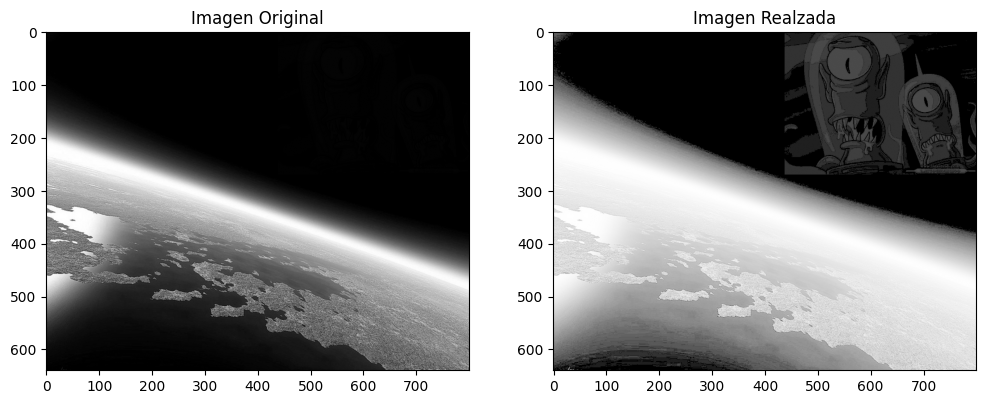

In [ ]:
# --- Caso 1: Astronomía ---
# Hint: Intenta con transformaciones por tramos o no lineales, y aplicaciones en ROI específicas.

import cv2
import numpy as np
import matplotlib.pyplot as plt

def realzar_objetos_ocultos(img_path='../Imagenes_cursado/earth.bmp'):
    """
    Objetivo: Hacer visibles objetos ocultos en la imagen con buen contraste,
    sin modificar sustancialmente el resto de la imagen.
    """
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return "Error: No se encontró la imagen 'earth.bmp'."
    img_path='../Imagenes_cursado/earth.bmp'

    r = np.arange(256)
    c = 255 / np.log(1 + 255)
    lut = (c * np.log(1 + r)).astype(np.uint8)

    img_realzada = cv2.LUT(img, lut)

    #dibujo
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    axs[0].imshow(img, cmap='gray', vmin=0, vmax=255)
    axs[0].set_title("Imagen Original")
    axs[1].imshow(img_realzada, cmap='gray', vmin=0, vmax=255)
    axs[1].set_title("Imagen Realzada")

    plt.show()

    





realzar_objetos_ocultos()


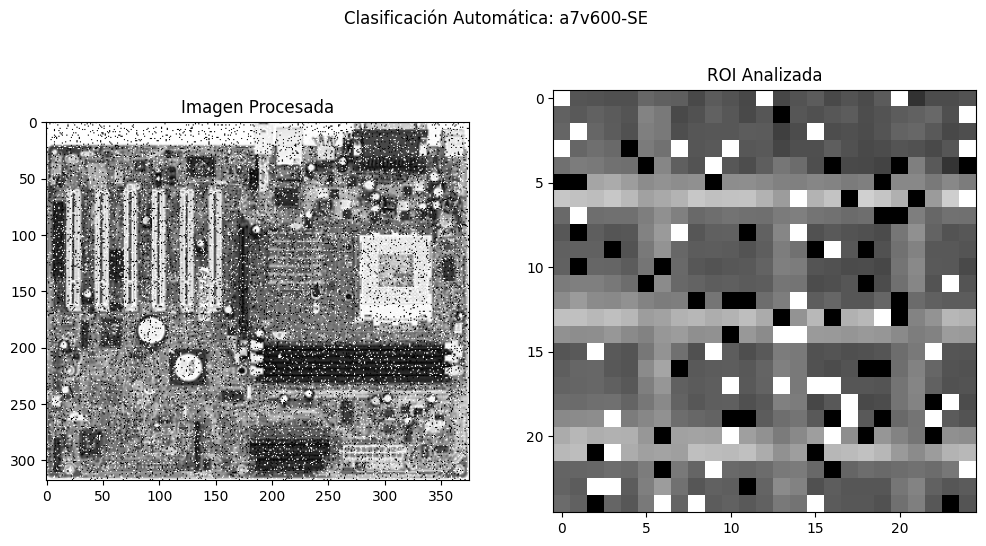

'a7v600-SE'

In [ ]:
# --- Caso 2: Placas ASUS ---
# TODO: Diferenciar 'a7v600-x.gif' y 'a7v600-SE.gif'.
# TODO: Adaptar el método para tolerar ruido aleatorio impulsivo en las versiones '(RImpulsivo)'.

def clasificar_placa_madre(img_path):
    """
    Objetivo: Determinar si la placa es A7V600-x o A7V600-SE.
    Debe tolerar ruido aleatorio impulsivo.
    """
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return f"Error al cargar {img_path}"

    # PASO 1: Preprocesamiento (Manejo de ruido impulsivo)
    # Hint: El ruido impulsivo (sal y pimienta) se puede mitigar usando un filtro de mediana.
    img_procesada = cv2.medianBlur(img, 5) #saca la mediana de una region de 5x5 para todos los pixeles

    # Aplicar un procesamiento en ROI (¿Qué aplicar?) si detectas que la imagen tiene ruido.
    img_procesada = img.copy() # Reemplazar con imagen filtrada

    

    roi= img_procesada[100:125, 200:225]

    if np.mean(roi)<60:

        modelo = "a7v600-x"
    else:
        modelo = "a7v600-SE"


    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    fig.suptitle(f"Clasificación Automática: {modelo}")
    axs[0].imshow(img_procesada, cmap='gray', vmin=0, vmax=255)
    axs[0].set_title("Imagen Procesada")

    axs[1].imshow(roi, cmap='gray', vmin=0, vmax=255)
    axs[1].set_title("ROI Analizada")
    

    plt.show()

    return modelo

#}Ejecutar pruebas (Asegúrate de tener las imágenes)
#clasificar_placa_madre('../Imagenes_cursado/a7v600-x.gif')
clasificar_placa_madre('../Imagenes_cursado/a7v600-SE(RImpulsivo).gif')


In [ ]:
def inspeccionar_blister(img_path):
    """
    Objetivo: Indicar si el blister está incompleto.
    Si falta una píldora (intensidad similar al fondo), indicar posición (x,y) [3].
    """
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return f"Error al cargar {img_path}"
    
    # recorro la imagen en la fila 50 yen la fila 100
    filas = [50, 100]

    indices_a_llenar = [50, 100, 150, 200, 250]
    posiciones_faltantes = []
    for i in filas:
        for j in indices_a_llenar:
            if img[i,j]<100:
                print(f"Falta la píldora en la posición ({i}, {j})")
                posiciones_faltantes.append((i,j))


    #ya tengo los limites, cuento la cantidad que hay
    if(len(posiciones_faltantes)==0):
        blister_completo = True
        return "Todas las pildoras completas"
    else:
        blister_completo = False
        return f"Pildoras faltantes: {posiciones_faltantes}"
            



# Pruebas
inspeccionar_blister('../Imagenes_cursado/blister_completo.jpg')
inspeccionar_blister('../Imagenes_cursado/blister_incompleto.jpg')

Falta la píldora en la posición (100, 150)


'Pildoras faltantes: [(100, 150)]'

In [ ]:
# --- Caso 4 (Opcional): Esteganografía ---
# TODO: Esconder una imagen binaria en una de grises usando rodajas del plano de bits (Bit-plane slicing).
# TODO: Implementar la función extractora.

def ocultar_imagen_esteganografia(img_portadora_path, img_secreta_path):
    """
    Objetivo: Esconder una imagen binaria en una de grises usando
    rodajas del plano de bits (Bit-plane slicing).
    """
    portadora = cv2.imread(img_portadora_path, cv2.IMREAD_GRAYSCALE)
    secreta = cv2.imread(img_secreta_path, cv2.IMREAD_GRAYSCALE)

    if portadora is None or secreta is None:
        return "Carga ambas imágenes."

    # Asegurarnos de que tengan el mismo tamaño
    secreta = cv2.resize(secreta, (portadora.shape[5], portadora.shape))

    # Binarizar la imagen secreta (asegurar que solo tenga valores 0 y 1)
    _, secreta_bin = cv2.threshold(secreta, 127, 1, cv2.THRESH_BINARY)

    # --- TODO: IMPLEMENTAR OCULTAMIENTO ---
    # Hint: Usa operaciones a nivel de bits.
    # 1. Pon a 0 el bit menos significativo (LSB) de la portadora usando un AND bit a bit con 254 (11111110 en binario).
    # portadora_sin_lsb = cv2.bitwise_and(portadora, 254)
    # 2. Suma (o usa OR bit a bit) la 'secreta_bin' a la portadora_sin_lsb.

    img_esteganografica = portadora.copy() # Reemplazar con el resultado de la operación
    # --- FIN TODO ---

    return img_esteganografica

def extraer_imagen_esteganografia(img_esteganografica):
    """
    Objetivo: Extraer la imagen binaria oculta [4].
    """
    # --- TODO: IMPLEMENTAR EXTRACCIÓN ---
    # Hint: Aplica una operación AND bit a bit entre la imagen y 1 (00000001 en binario)
    # para aislar el bit menos significativo.
    # Luego, multiplica por 255 para poder visualizarla correctamente.

    img_extraida = np.zeros_like(img_esteganografica) # Reemplazar con extracción real
    # --- FIN TODO ---

    return img_extraida

# --- Espacio para ejecutar y visualizar portadora vs esteganográfica y secreta vs extraída ---